# MNQ Bollinger Band mean-reversion, 60-minute bars (Tradovate exchange)

Same strategy and methodology as `bollinger_mean_reversion_mes_30m.ipynb`,
which found the **strongest walk-forward-confirmed result in this entire
research program** (`trade_sharpe_lb=+0.0831`, more than 3x the previous best
in this repo). This notebook re-runs the identical escalating-refinement
process -- indicator hyperparameters, then SL/TP, then direction, then
holdout, then walk-forward if promising -- on MNQ at
60-minute bars.

**Mechanism** (`BollingerMeanReversionStrategy`): fades an extension to the
outer Bollinger Band (touch lower band -> long, touch upper -> short), fixed
fractional-distance stop-loss/take-profit (`sl_percent`/`tp_percent`).


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import BollingerMeanReversionStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MNQ"
SYMBOL = "MNQ/USD"
INTERVAL = 60
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 42246  span: 2019-05-05 22:59:59.999000 -> 2026-07-13 07:59:59.999000


## Phase 1: grid the indicator's own hyperparameters (bb_length x bb_std_dev)

`sl_percent=0.01`, `tp_percent=0.01` fixed at placeholder values for this
pass -- tuned properly in Phase 2. `direction=both`.


In [3]:
BB_LENGTH_CANDIDATES = [10, 20, 30, 50]
BB_STD_DEV_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
PLACEHOLDER_SL_PERCENT = 0.01
PLACEHOLDER_TP_PERCENT = 0.01
DEPOSIT_USD = 50_000


def run_bmr_backtest(ohlc_slice: pd.DataFrame, bb_length: int, bb_std_dev: float, sl_percent: float, tp_percent: float,
                      key: str, direction: StrategyDirection = StrategyDirection.both):
    lower, _middle, upper = Indicators.bollinger_bands(ohlc_slice, length=bb_length, std_dev=bb_std_dev)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_lower", df=lower)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_upper", df=upper)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=BollingerMeanReversionStrategy(
            key=key, market=market, symbol=SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=sl_percent, tp_percent=tp_percent, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
        "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
    })
    return row


grid1_rows = []
grid1_backtests = {}
_t0 = time.time()
for bb_length in BB_LENGTH_CANDIDATES:
    for bb_std_dev in BB_STD_DEV_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, bb_length, bb_std_dev, PLACEHOLDER_SL_PERCENT, PLACEHOLDER_TP_PERCENT,
                                             key=f"BMR_ind_{bb_length}_{bb_std_dev}")
        grid1_backtests[(bb_length, bb_std_dev)] = (bt, drawdown_mw)
        grid1_rows.append(_summarize(bt, drawdown_mw, bb_length=bb_length, bb_std_dev=bb_std_dev))
    print(f"bb_length={bb_length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid1_results = pd.DataFrame(grid1_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 1 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid1_results.to_string())


bb_length=10 done, 16s elapsed


bb_length=20 done, 33s elapsed


bb_length=30 done, 48s elapsed


bb_length=50 done, 62s elapsed



phase 1 grid done in 62s

    bb_length  bb_std_dev  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0          20         3.0           -1.412446      0.015867              -22.8084         1025.0            142.4         57.951220       1.390084               0.163272              1.011697           2.113050         2713.62           False
1          10         3.0           -4.110348     -0.028706              -17.4729          955.0            132.6         63.350785       1.742456               0.271027              1.002118           0.366510         2369.64           False
2          10         2.5          -13.290182     -0.133895              -29.9681         1530.0            212.5         60.326797       1.533939               0.210877              0.981331          -2.743582         3097.64           False
3

### Heatmaps: Sharpe ratio and net return across (bb_length, bb_std_dev)


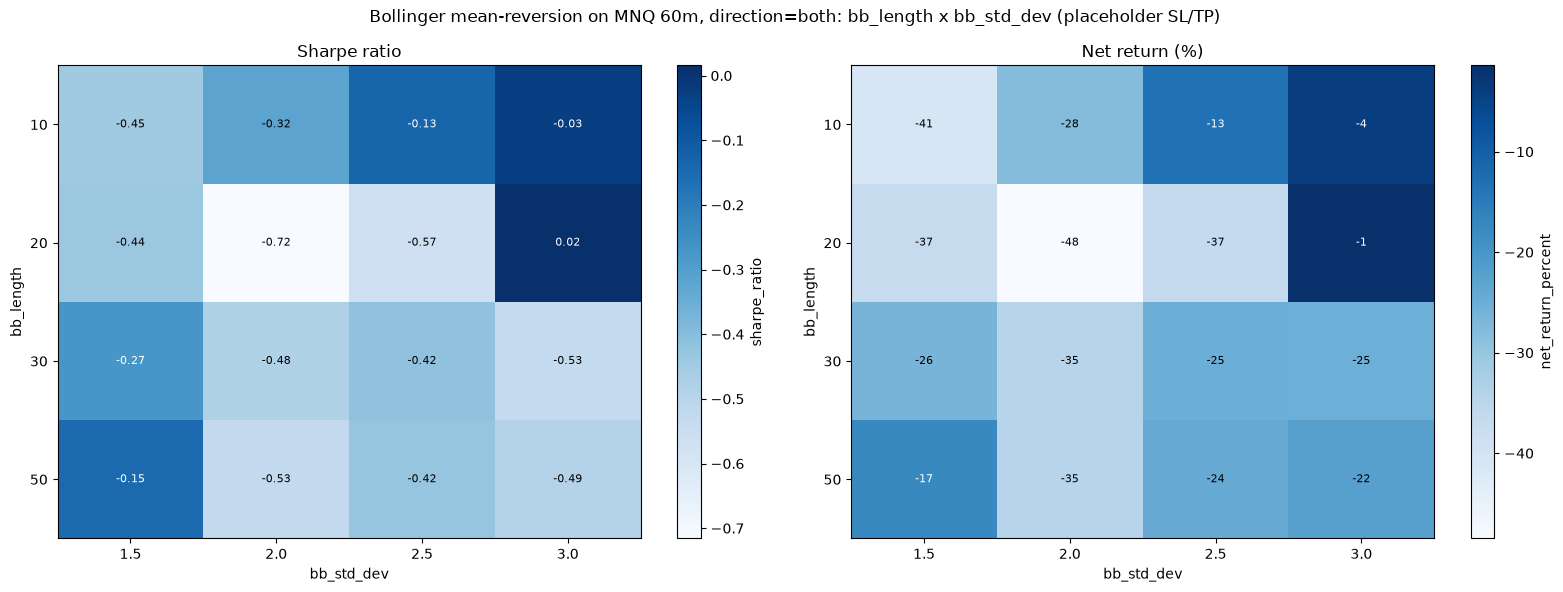

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str, xlabel: str, ylabel: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="sharpe_ratio")
return_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f", "bb_std_dev", "bb_length")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f", "bb_std_dev", "bb_length")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("Bollinger mean-reversion on MNQ 60m, direction=both: bb_length x bb_std_dev (placeholder SL/TP)")
fig.tight_layout()
plt.show()


## Phase 2: grid SL/TP on the best (bb_length, bb_std_dev) combo

Holding the indicator shape fixed at Phase 1's winner, grids `sl_percent` x
`tp_percent` directly.


In [5]:
best_bb_length, best_bb_std_dev = grid1_results.iloc[0][["bb_length", "bb_std_dev"]]
best_bb_length = int(best_bb_length)
best_bb_std_dev = float(best_bb_std_dev)
print(f"Phase 1 winner: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}")

SL_PERCENT_CANDIDATES = [0.005, 0.01, 0.015, 0.02]
TP_PERCENT_CANDIDATES = [0.0025, 0.005, 0.0075, 0.01]

grid2_rows = []
grid2_backtests = {}
_t0 = time.time()
for sl_percent in SL_PERCENT_CANDIDATES:
    for tp_percent in TP_PERCENT_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, best_bb_length, best_bb_std_dev, sl_percent, tp_percent,
                                             key=f"BMR_sltp_{sl_percent}_{tp_percent}")
        grid2_backtests[(sl_percent, tp_percent)] = (bt, drawdown_mw)
        grid2_rows.append(_summarize(bt, drawdown_mw, sl_percent=sl_percent, tp_percent=tp_percent))
    print(f"sl_percent={sl_percent} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid2_results = pd.DataFrame(grid2_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 2 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid2_results.to_string())


Phase 1 winner: bb_length=20, bb_std_dev=3.0


sl_percent=0.005 done, 15s elapsed


sl_percent=0.01 done, 30s elapsed


sl_percent=0.015 done, 50s elapsed


sl_percent=0.02 done, 74s elapsed



phase 2 grid done in 74s

    sl_percent  tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0        0.010      0.0100           -1.412446      0.015867              -22.8084         1025.0            142.4         57.951220       1.390084               0.163272              1.011697           2.113050         2713.62           False
1        0.010      0.0075           -5.819775     -0.065246              -25.4491         1153.0            160.1         65.221162       1.417155               0.144419              0.997802          -0.292341         2611.70           False
2        0.005      0.0050           -8.790129     -0.169831              -21.3390         1531.0            212.6         60.744611       1.553893               0.216938              0.988254          -0.916635         3170.44           Fal

### Heatmaps: Sharpe ratio and net return across (sl_percent, tp_percent)


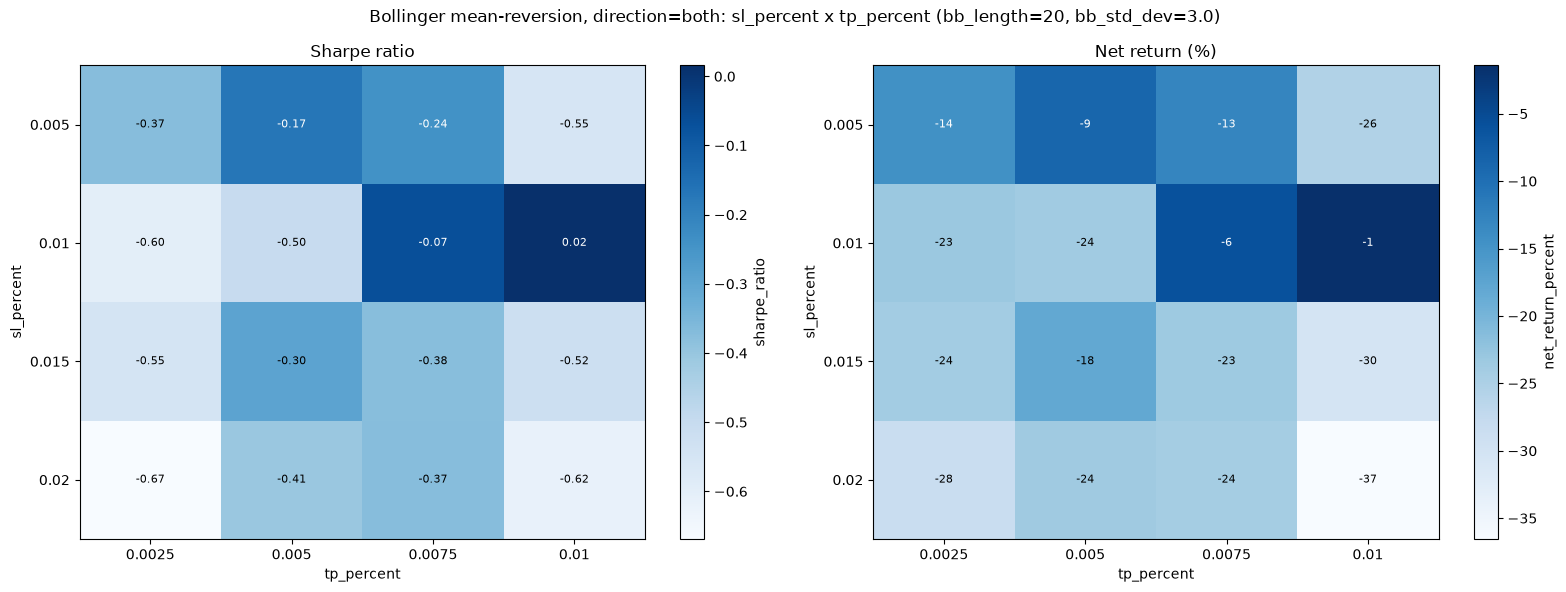

In [6]:
sharpe_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="sharpe_ratio")
return_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot2, "Sharpe ratio", ".2f", "tp_percent", "sl_percent")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot2, "Net return (%)", ".0f", "tp_percent", "sl_percent")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"Bollinger mean-reversion, direction=both: sl_percent x tp_percent (bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev})")
fig.tight_layout()
plt.show()


## Detailed report for the overall best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (bb_length, bb_std_dev, sl_percent, tp_percent) combo across both grids.


Best combo: bb_length=20, bb_std_dev=3.0, sl_percent=0.01, tp_percent=0.01
Candles Processed: 42245
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MNQ/USD,description
sharpe_ratio,0.0159,0.5128,1.0014,-0.2349,-0.3863,-1.0839,1.1399,-0.6683,-0.2852,0.7258,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.0221,0.7778,1.5222,-0.3214,-0.5134,-1.4166,1.7140,-0.8743,-0.3638,1.0487,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,7.0465,7.0846,7.4670,6.5187,8.4042,7.0356,7.3201,6.9048,2.8410,20.8025,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-0.1975,5.0224,11.0217,-2.5006,-5.0939,-10.8068,12.4441,-6.8061,-1.2306,20.6027,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.0087,0.9745,1.6130,-0.3249,-0.5099,-0.8621,3.0102,-0.8597,-0.5975,0.5814,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.0619,0.6354,1.6130,-0.3240,-0.5085,-0.8598,3.0102,-0.8575,-0.3169,8.0398,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-22.8084,-5.1537,-6.8328,-7.6962,-9.9902,-12.5361,-4.1340,-7.9166,-2.0595,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,1841,122,143,186,362,360,83,361,114,751,How long it took to recover the loss. Shorter is better.
ulcer_index,13.1299,2.4020,3.1652,3.2508,6.5390,7.3460,1.8687,5.4165,0.8870,11.9943,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.8054,-0.7515,-0.8084,-0.7725,-1.0120,-0.7726,-0.7943,-0.8345,0.0000,-2.0294,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


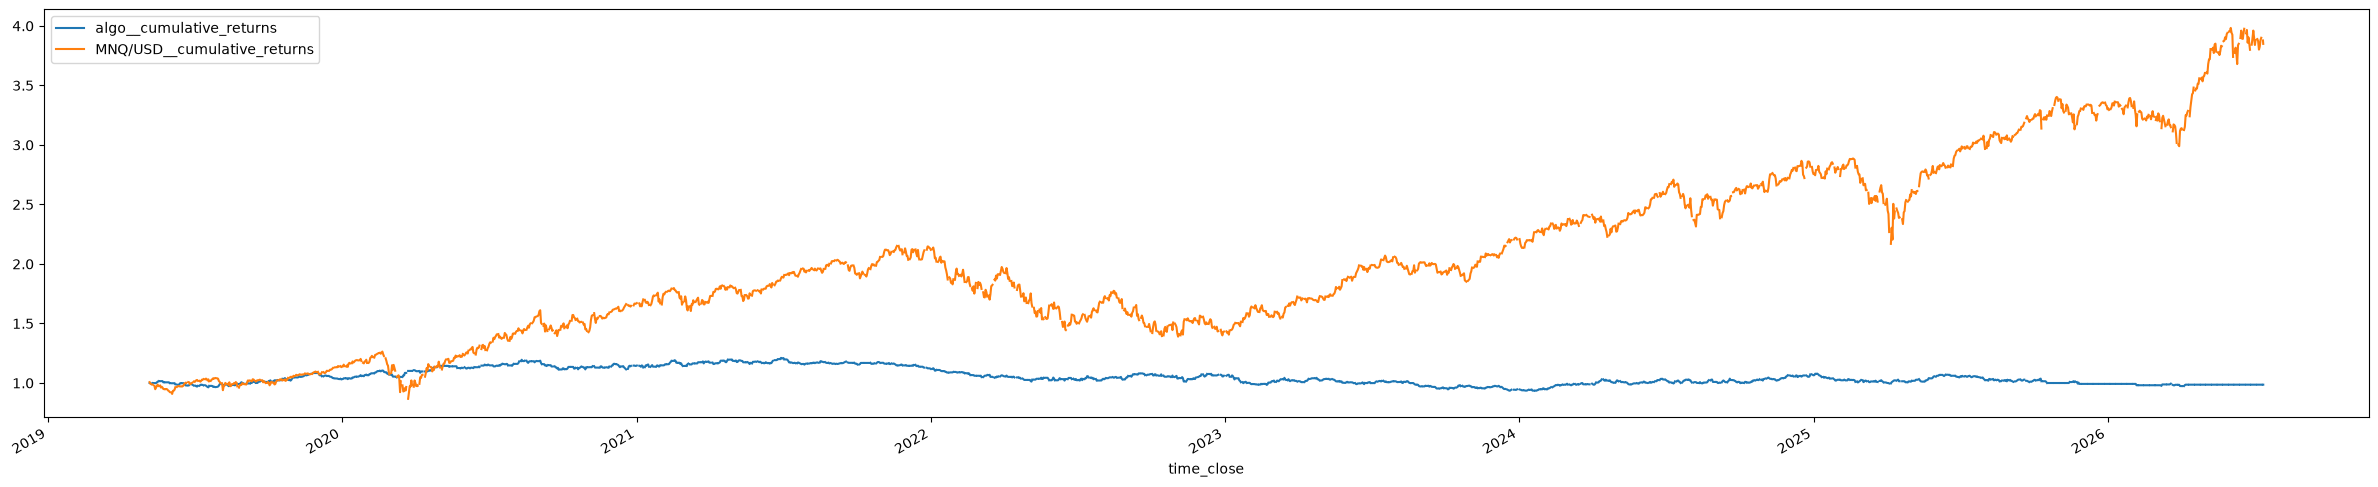

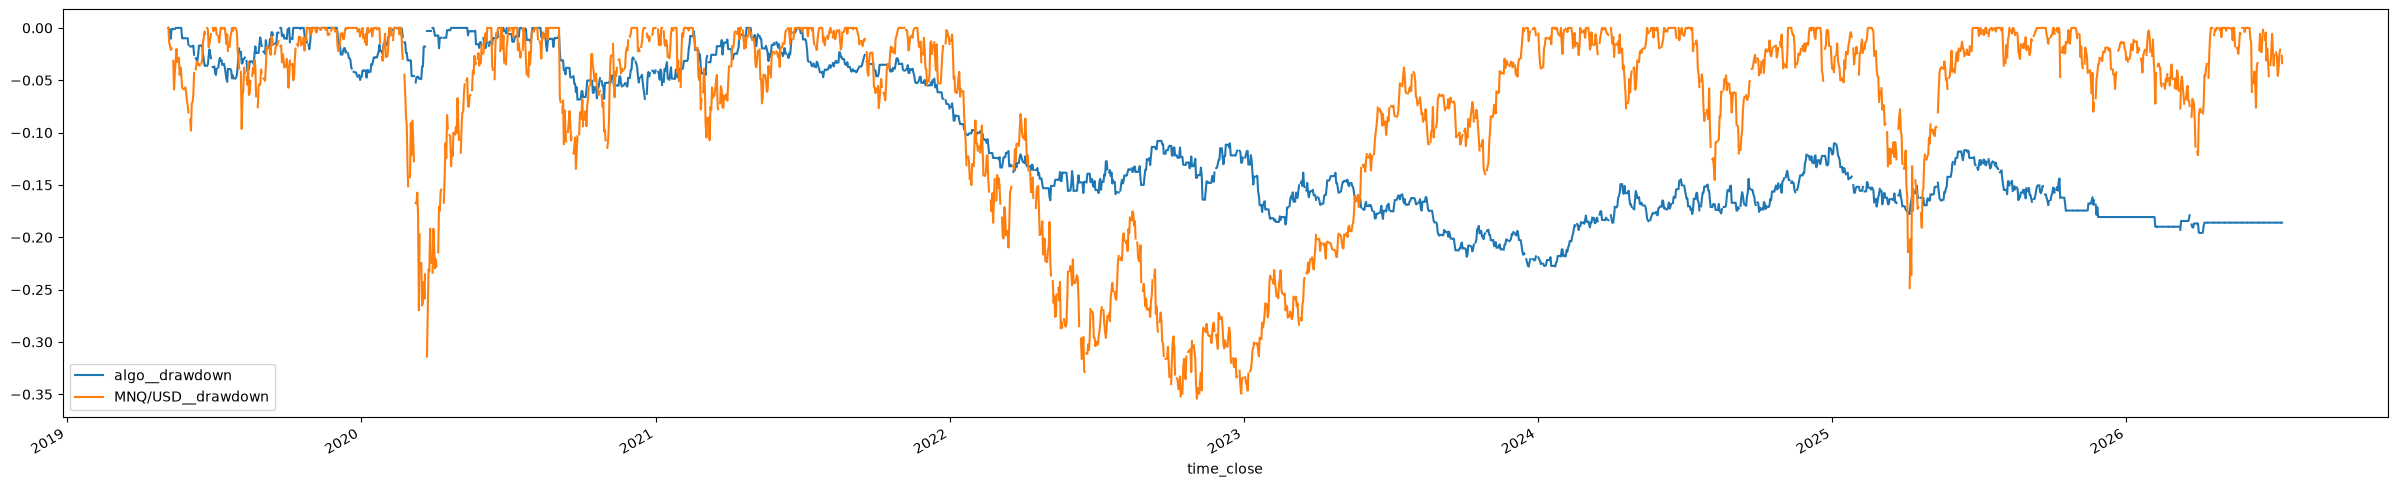

In [7]:
best_sl_percent, best_tp_percent = grid2_results.iloc[0][["sl_percent", "tp_percent"]]
best_sl_percent = float(best_sl_percent)
best_tp_percent = float(best_tp_percent)
print(f"Best combo: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}, sl_percent={best_sl_percent}, tp_percent={best_tp_percent}")
best_backtest, best_drawdown_mw = grid2_backtests[(best_sl_percent, best_tp_percent)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Direction comparison: both vs. long-only vs. short-only

Holding (bb_length, bb_std_dev, sl_percent, tp_percent) fixed at the overall
best combo, re-runs with `direction=long` and `direction=short`.


In [8]:
direction_rows = []
direction_backtests = {}
for direction in [StrategyDirection.both, StrategyDirection.long, StrategyDirection.short]:
    bt, drawdown_mw = run_bmr_backtest(ohlc, best_bb_length, best_bb_std_dev, best_sl_percent, best_tp_percent,
                                         key=f"BMR_dir_{direction.value}", direction=direction)
    direction_backtests[direction] = (bt, drawdown_mw)
    direction_rows.append({"direction": direction.value, **_summarize(bt, drawdown_mw)})

direction_df = pd.DataFrame(direction_rows).set_index("direction")
print(direction_df.to_string())


           net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
direction                                                                                                                                                                                                                         
both                -1.412446      0.015867              -22.8084         1025.0            142.4         57.951220       1.390084               0.163272              1.011697           2.113050         2713.62           False
long                -0.827844      0.016856              -18.6128          698.0             96.9         59.312321       1.457746               0.186246              1.011108           1.851151         1665.30           False
short              -22.187198     -0.529381              -26.3464          509.0            

## Holdout check: does the best (combo, direction) survive a train/test split?

Uses whichever of both/long/short scored highest above.


In [9]:
best_direction_label = direction_df["sharpe_ratio"].idxmax()
best_direction = StrategyDirection(best_direction_label)
print(f"Best direction: {best_direction_label}")

split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_bmr_backtest(ohlc_slice, best_bb_length, best_bb_std_dev, best_sl_percent, best_tp_percent,
                                         key=f"BMR_holdout_{label}", direction=best_direction)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


Best direction: long
train/test split at 2024-09-22 23:59:59.999000  (31684 train bars, 10562 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                        698         59.312321      0.189427         0.126607        0.016856           -0.827844              1.011108           1.851151              -18.6128           False
TRAIN (75%)                 525         59.238095      0.187819         0.115395       -0.028404           -2.700573              1.000549           0.086465              -18.6128           False
TEST (last 25%, unseen)     173         59.537572      0.193757         0.067522       -0.053670           -1.322623              0.987738          -2.530735              -17.3629           False


## Findings

**Also weak on MNQ -- hourly bars dilute this strategy's sample too much
on both symbols.** Best combo (`bb_length=20, bb_std_dev=3.0,
sl_percent=0.01, tp_percent=0.01`): FULL Sharpe **0.016**, net return
actually slightly negative (-1.4% both-direction, -0.8% long-only) --
essentially flat, not a real edge.

**Direction comparison**: `long` (0.017) barely edges out `both` (0.016);
`short` is clearly bad (-0.529), same pattern as every other symbol/interval
tested so far.

**Holdout is a study in noise around zero**: TRAIN `trade_sharpe_lb`=+0.115
and TEST `trade_sharpe_lb`=+0.068 both look positive on a per-trade basis,
but account-level net return is negative in both windows (TRAIN -2.7%, TEST
-1.3%) -- the per-trade Sharpe lower bound and the realized account return
are telling different stories on a sample this thin (525/173 trades), which
is itself a sign there isn't enough signal here to trust either number.

**Bottom line**: matches MES 1h's finding exactly -- hourly bars are too
coarse for this strategy on either symbol. The 30-minute version remains the
only interval where this mechanism has shown a real, confirmed edge. Not
walk-forwarding this one.